# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


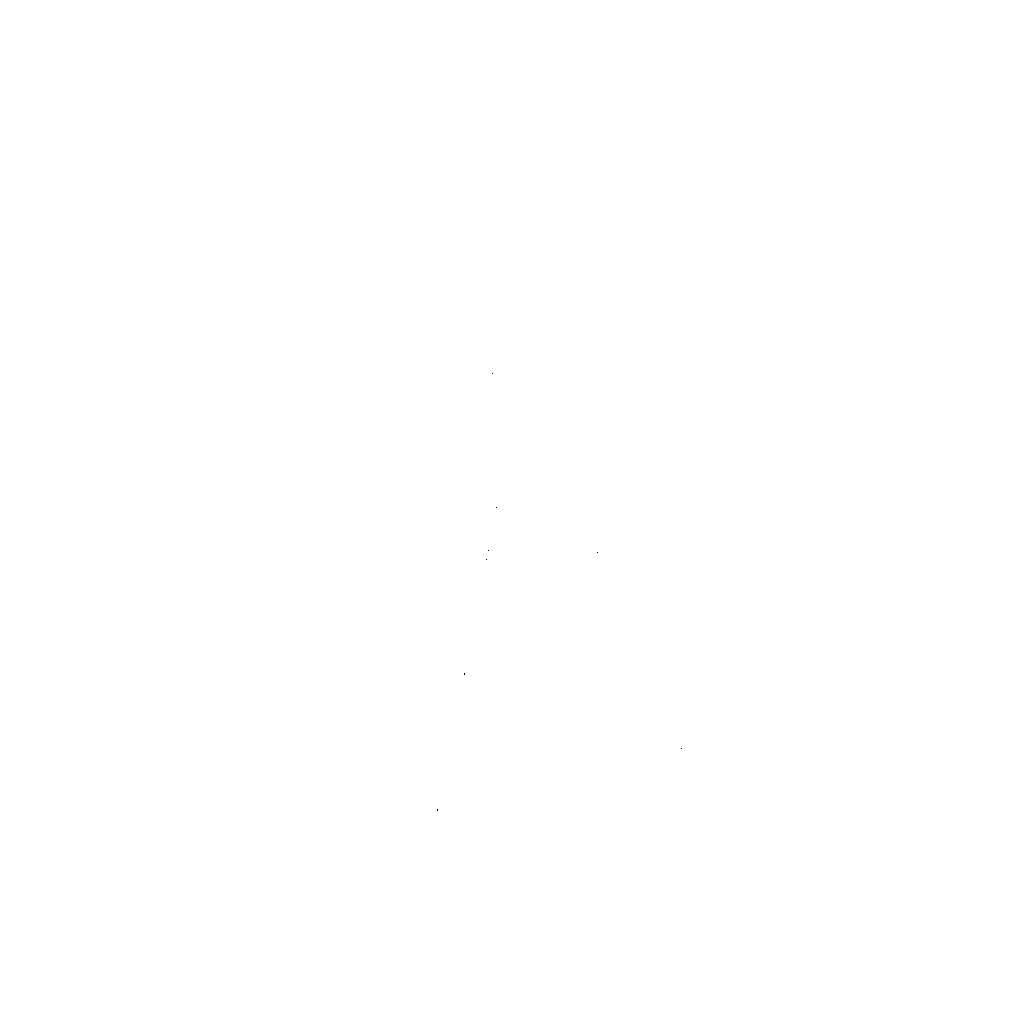

Threshold value: 50


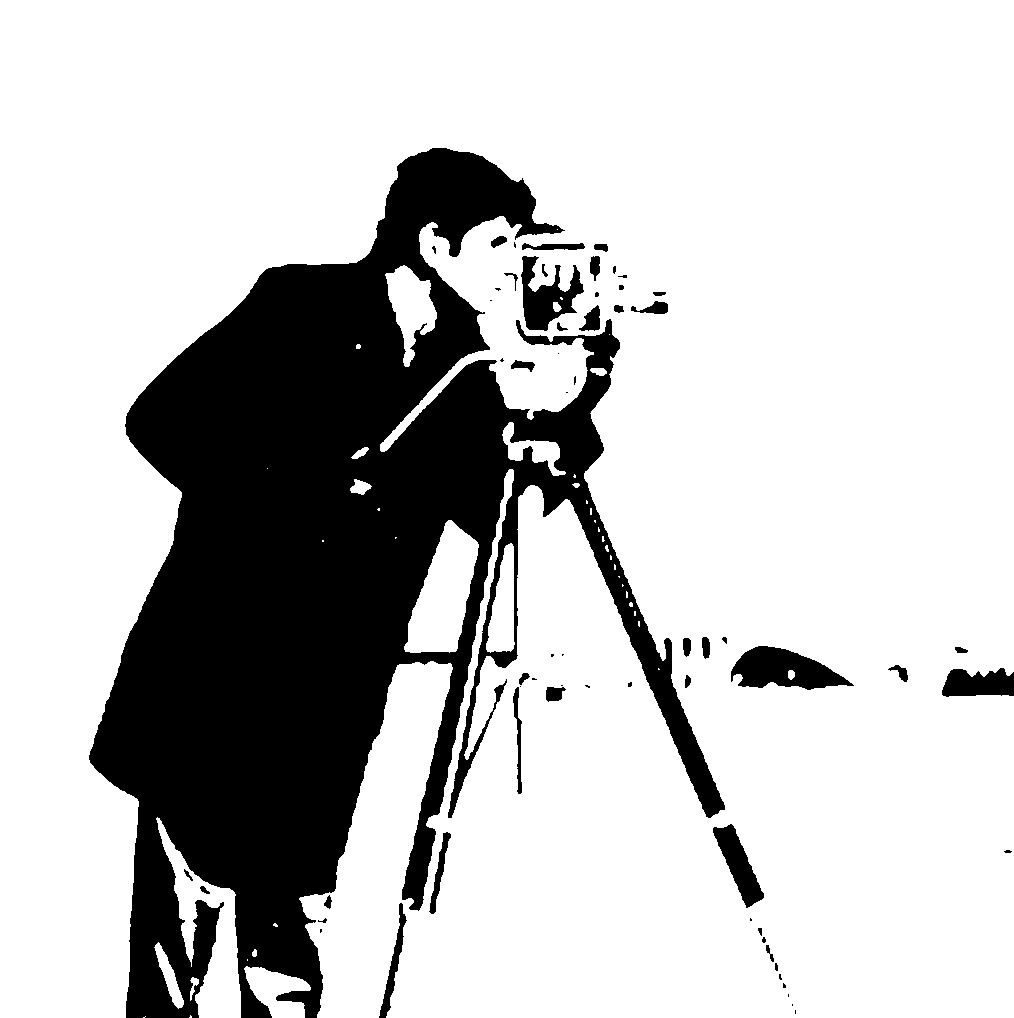

Threshold value: 100


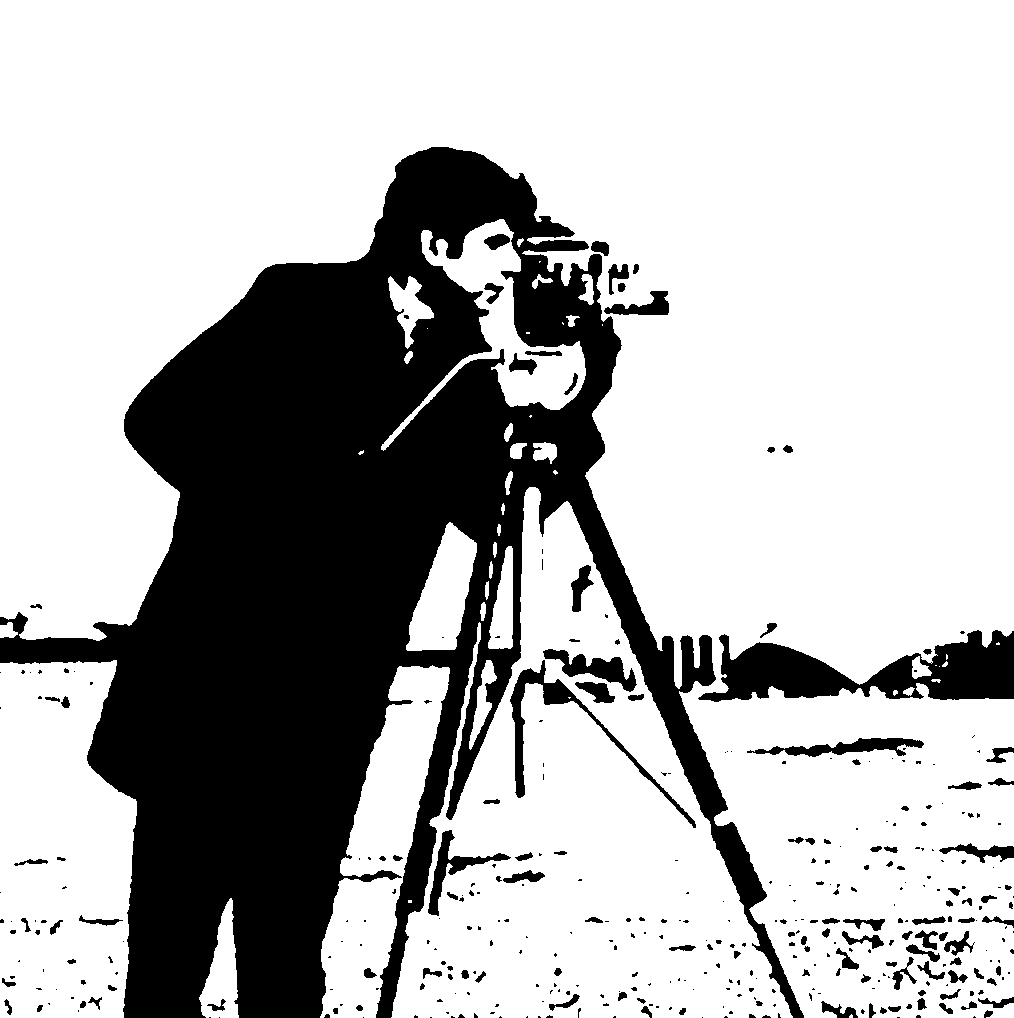

Threshold value: 150


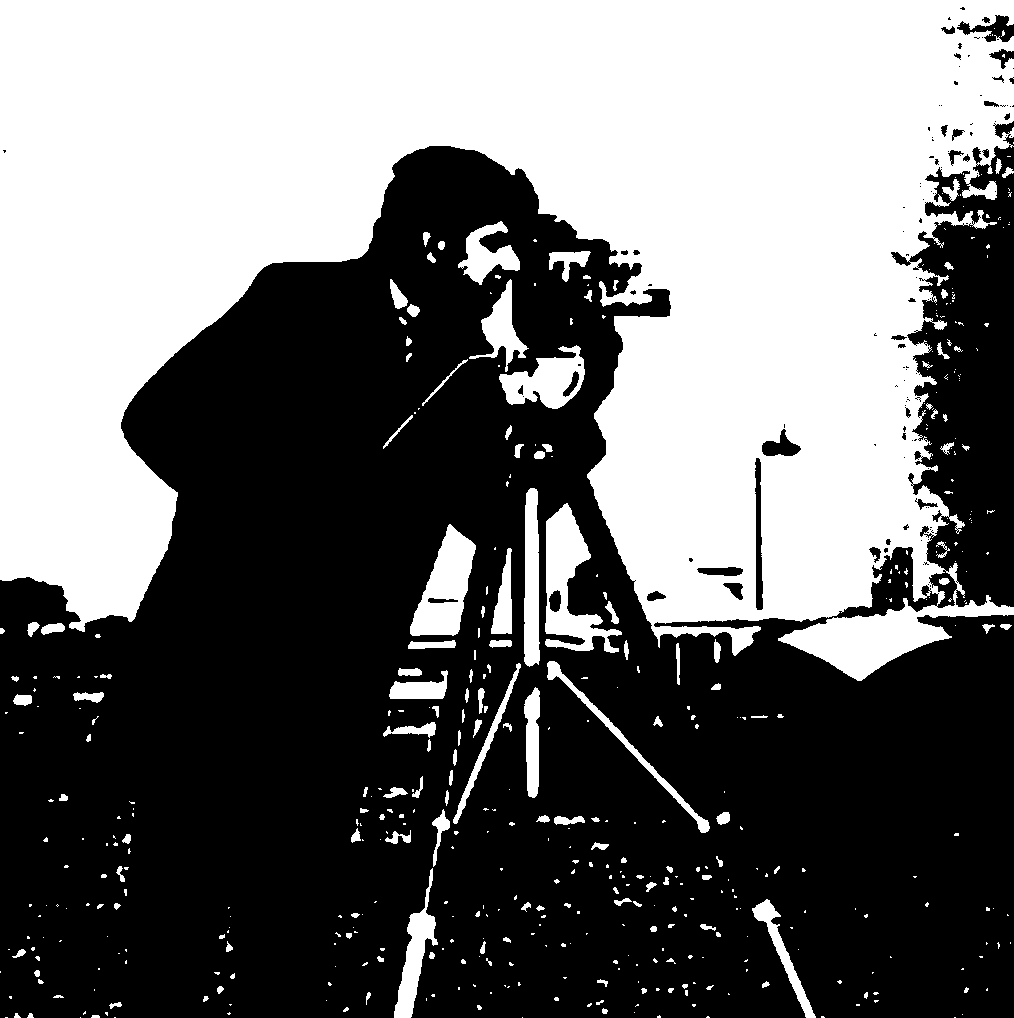

Threshold value: 200


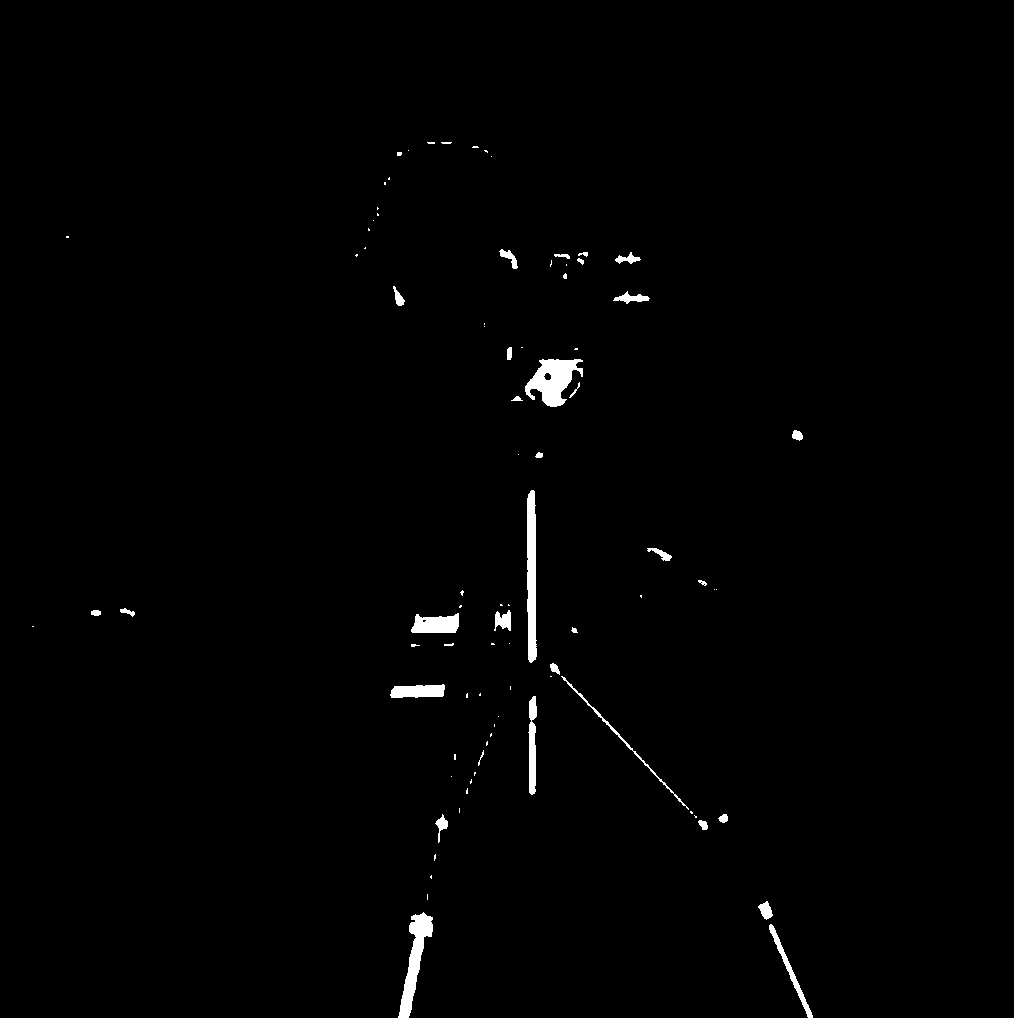

In [9]:
import cv2
from google.colab.patches import cv2_imshow

# Load the image in grayscale
img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)

# Set the threshold values
threshold_values = [0, 50, 100, 150, 200]

# Apply thresholding with different threshold values
for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(
        img,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    print(f"Threshold value: {threshold_value}")
    cv2_imshow(thresh_img)

Original Image: 


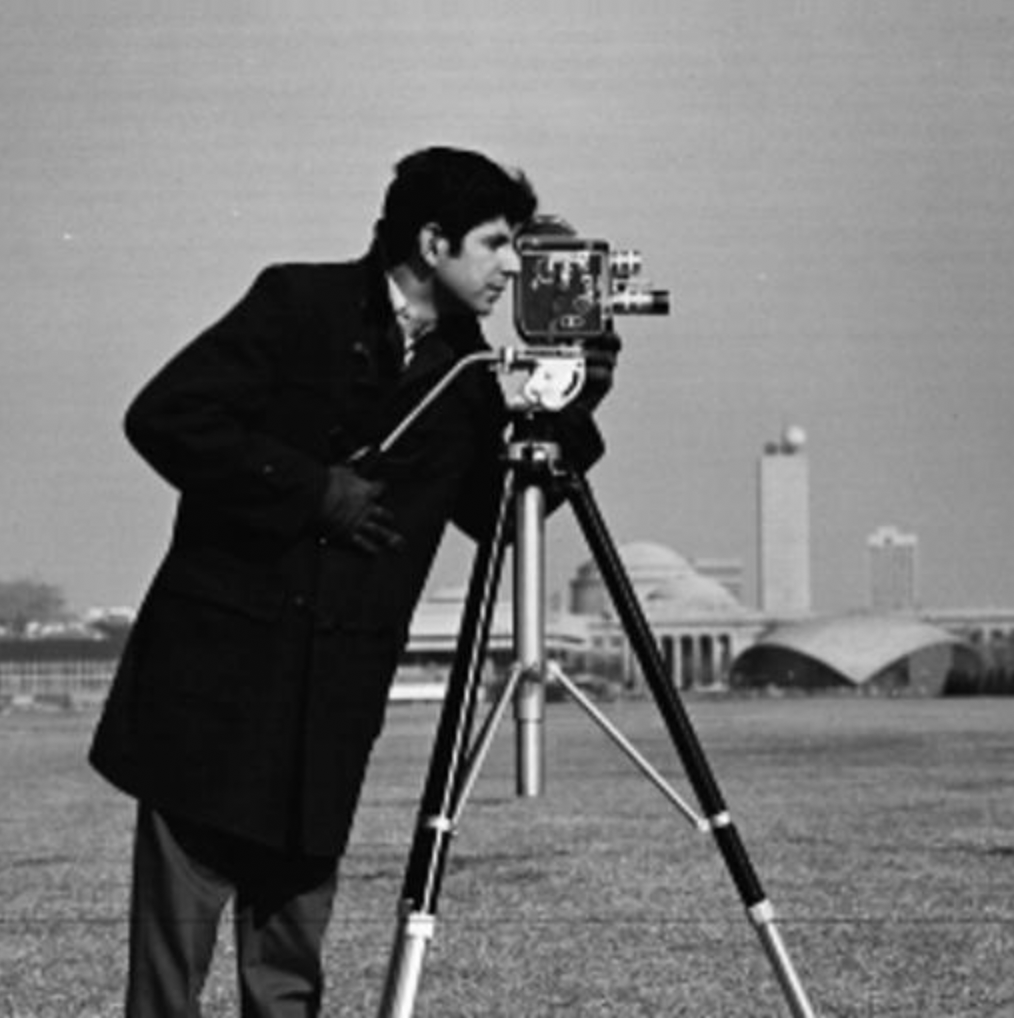

In [10]:
print("Original Image: ")
cv2_imshow(img)

## Histograms

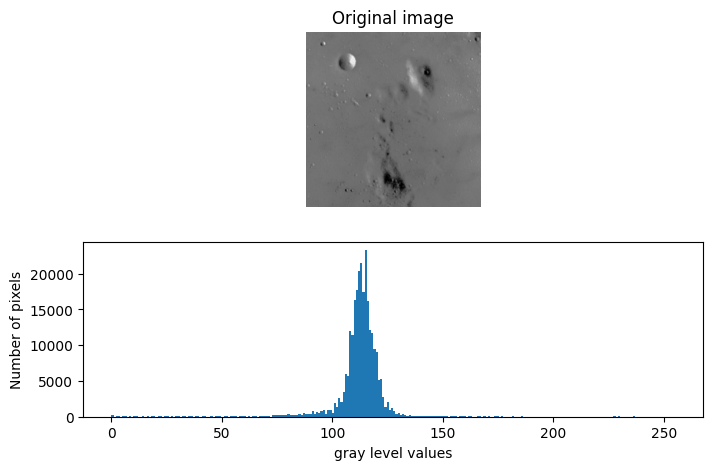

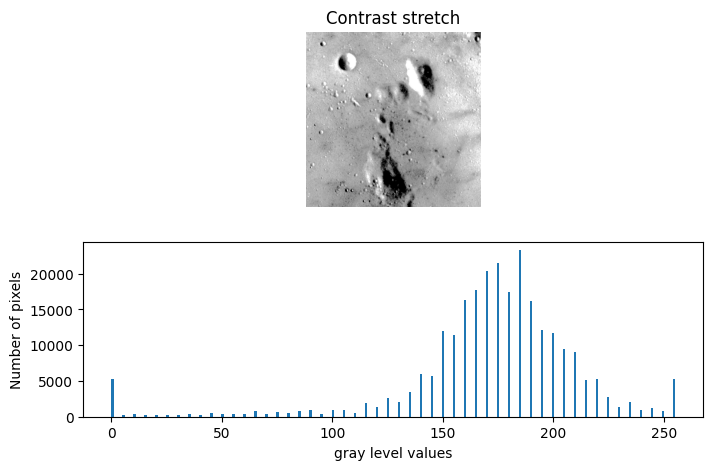

In [11]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.exposure import match_histograms
from skimage import data, exposure
moon = data.moon()
moon = img

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

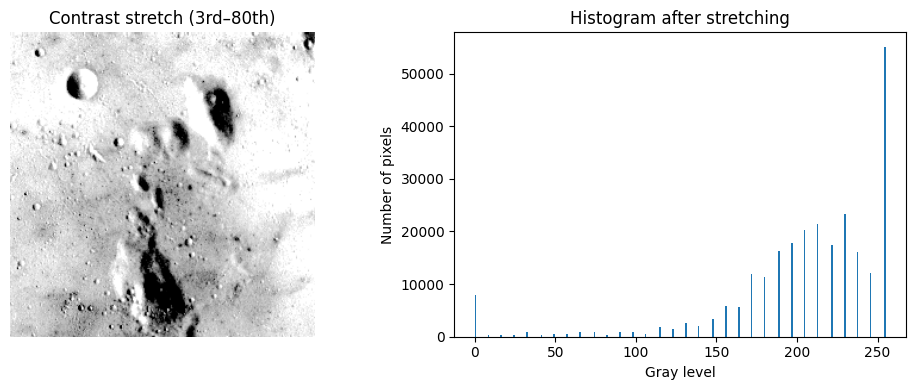

3rd percentile = 87.0
80th percentile = 118.0


In [13]:
p3, p80 = np.percentile(moon, (3, 80))
moon_task1 = exposure.rescale_intensity(moon, in_range=(p3, p80))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(moon_task1, cmap='gray')
ax[0].set_title(f'Contrast stretch (3rd–80th)')
ax[0].axis('off')
ax[1].hist(moon_task1.ravel(), bins=256, range=(0, 255))
ax[1].set_title('Histogram after stretching')
ax[1].set_xlabel('Gray level')
ax[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

print('3rd percentile =', p3)
print('80th percentile =', p80)

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

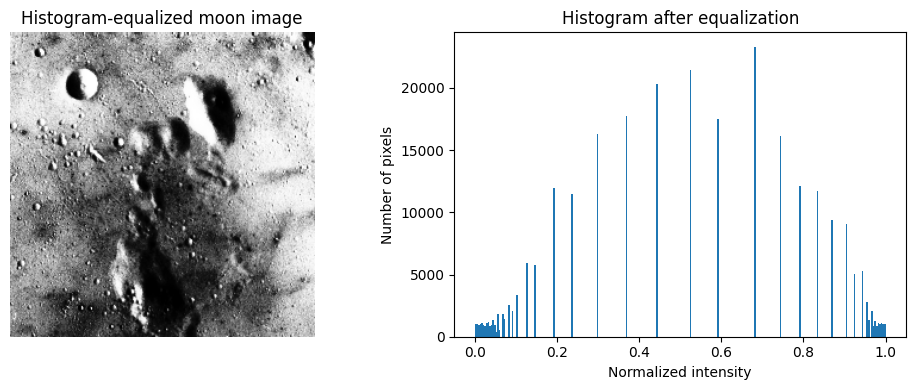

In [14]:
moon_equalized = exposure.equalize_hist(moon)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(moon_equalized, cmap='gray')
ax[0].set_title('Histogram-equalized moon image')
ax[0].axis('off')
ax[1].hist(moon_equalized.ravel(), bins=256, range=(0, 1))
ax[1].set_title('Histogram after equalization')
ax[1].set_xlabel('Normalized intensity')
ax[1].set_ylabel('Number of pixels')
plt.tight_layout()
plt.show()

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


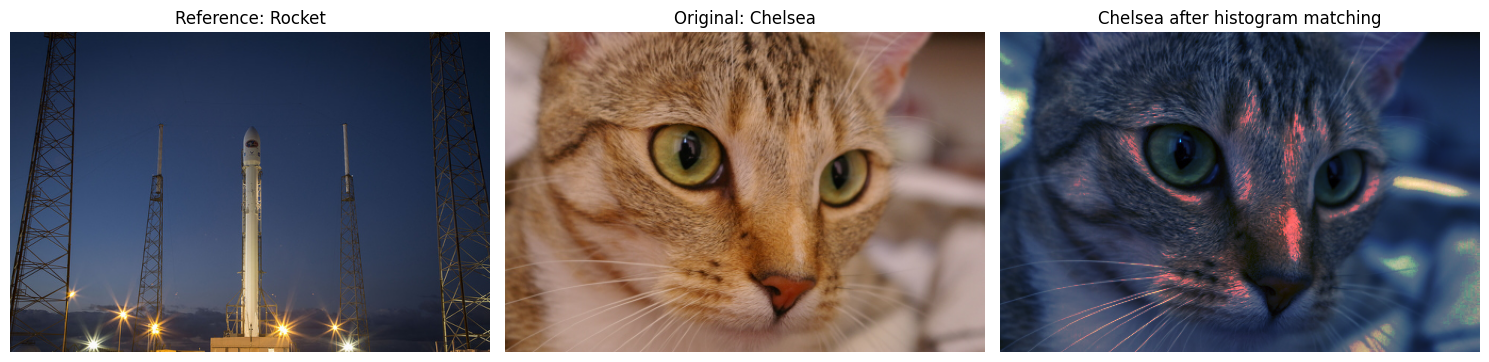

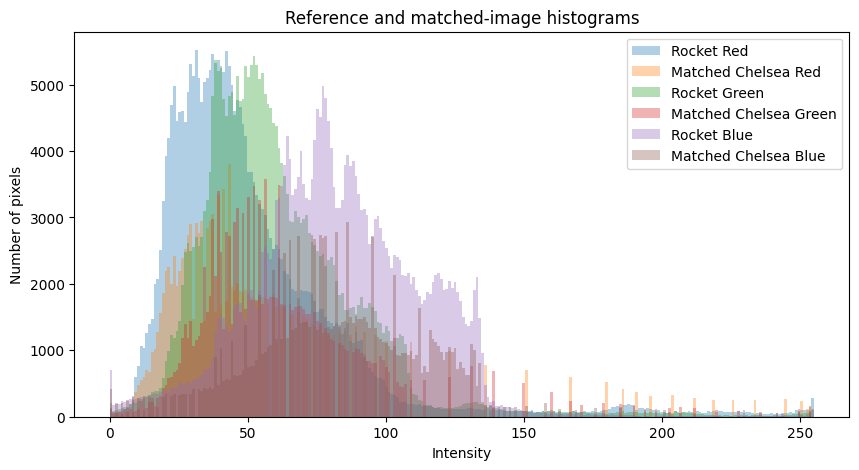

In [15]:
rocket = data.rocket()
chelsea = data.chelsea()

chelsea_matched = match_histograms(chelsea, rocket, channel_axis=-1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rocket)
ax[0].set_title('Reference: Rocket')
ax[0].axis('off')
ax[1].imshow(chelsea)
ax[1].set_title('Original: Chelsea')
ax[1].axis('off')
ax[2].imshow(chelsea_matched)
ax[2].set_title('Chelsea after histogram matching')
ax[2].axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for channel, name in enumerate(['Red', 'Green', 'Blue']):
    plt.hist(rocket[..., channel].ravel(), bins=256, alpha=0.35, label=f'Rocket {name}')
    plt.hist(chelsea_matched[..., channel].ravel(), bins=256, alpha=0.35, label=f'Matched Chelsea {name}')
plt.title('Reference and matched-image histograms')
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')
plt.legend()
plt.show()
